In [47]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm
import statsmodels.graphics.mosaicplot as mosaic
from scipy import stats
import collections
import itertools

rng = np.random.default_rng()

# Block 3

## 1. Prac 6

#### 1. Низкий уровень холестерина липопротеидов высокой плотности (ХЛПВП) — фактор риска ишемической болезни сердца. Некоторые исследования свидетельствуют, что физическая нагрузка может повысить уровень ХЛПВП.
Дж. Хартунг и соавт. исследовали уровень ХЛПВП у бегунов-марафонцев, бегунов трусцой и лиц, не занимающихся спортом.
Средний уровень ХЛПВП у лиц, не занимающихся спортом, составил 43,3 мг% (стандартное отклонение 14,2 мг%), у бегунов трусцой — 58,0 мг% (стандартное отклонение 17,7 мг%) и у марафонцев — 64,8 мг% (стандартное отклонение 14,3 мг%).
Будем считать, что в каждой группе было по 70 человек.
Оцените статистическую значимость различий между группами. Найдите отличающиеся группы.

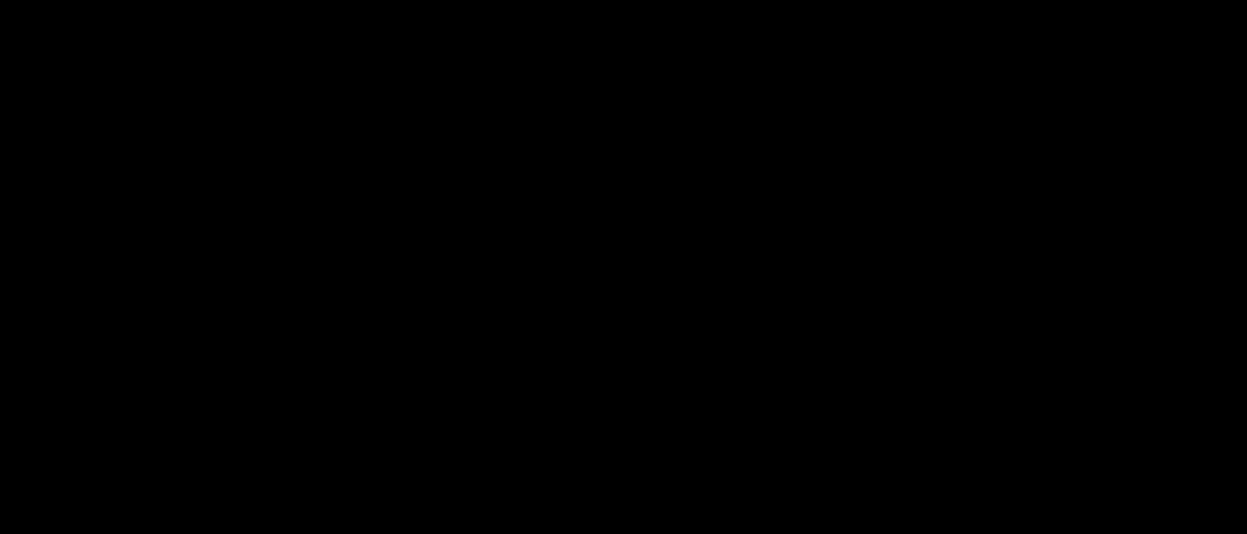

Проводим однофакторный дисперсионный анализ (ANOVA)
* $H_0: \mu_1 = \mu_2 = \mu_3$

In [98]:
means = np.array([43.3, 58., 64.8])
stds = np.array([14.2, 17.7, 14.3])
N = 70
k = 3

# means = np.array([11.5 ,10.1, 9.1])
# stds = np.array([1.3, 2.1, 2.4])
# N = 26
# k = 3

In [99]:
mean = means.sum() / k
mean

np.float64(55.36666666666667)

In [100]:
# внутри
msw_ = (stds ** 2 * (N - 1)) / (k * N - k)
msw = msw_.sum()
msw

np.float64(239.80666666666667)

In [101]:
# меж
msb_ = (means - mean) ** 2 * N / (k - 1)
msb = msb_.sum()
msb

np.float64(8453.433333333332)

In [102]:
F = msb / msw
F

np.float64(35.25103555642045)

In [103]:
dfb = k - 1
dfw = k * N - k
dfb, dfw, (F_crit := stats.f.ppf(1 - 0.05, dfb, dfw))

(2, 207, np.float64(3.039508254152564))

In [104]:
f"{F} > {F_crit} => {F > F_crit} - отвергаем H_0"

'35.25103555642045 > 3.039508254152564 => True - отвергаем H_0'

Есть различия в $\mu$

Применим метод Холма

In [105]:
SE = np.sqrt(msw / N)
SE

np.float64(1.8508942497640226)

In [106]:
combs = list(itertools.combinations(enumerate(zip(means, stds)), 2))
combs

[((0, (np.float64(43.3), np.float64(14.2))),
  (1, (np.float64(58.0), np.float64(17.7)))),
 ((0, (np.float64(43.3), np.float64(14.2))),
  (2, (np.float64(64.8), np.float64(14.3)))),
 ((1, (np.float64(58.0), np.float64(17.7))),
  (2, (np.float64(64.8), np.float64(14.3))))]

In [109]:
p_values = []
for (i, (mean_a, std_a)), (j, (mean_b, std_b)) in combs:
    sx = np.sqrt(((N - 1) * std_a ** 2 + (N - 1) * std_b ** 2) / (2 * N - 2))
    t = np.abs(mean_a - mean_b) / (sx * np.sqrt(2 / N))

    # t = np.abs(mean_a - mean_b) / np.sqrt(msw * 2 / N)
    print(i, j, stats.t.sf(t, 2 * N - 2))
    # print(mean_a, mean_b, sx)
    p_values.append(stats.t.sf(t, 2 * N - 2))

0 1 1.292509572402871e-07
0 2 1.220075514537288e-15
1 2 0.006790456265801702


In [114]:
# alpha = 0.05
[(i + 1) * x for i, x in enumerate(sorted(p_values))]

[np.float64(1.220075514537288e-15),
 np.float64(2.585019144805742e-07),
 np.float64(0.020371368797405108)]

Отклоняем все попарные нулевые гипотезы.
Все группы отличаются

#### 2. Работа медицинской сестры сопряжена с постоянным напряжением и тяжелыми переживаниями. Груз ответственности, не уравновешенной правом принимать решения, рождает чувство усталости, раздражения и безысходности, интересная некогда работа становится ненавистным бременем. Этот синдром не совсем точно называют опустошенностью. Считается, что его развитию особенно подвержены медицинские сестры, которые работают с наиболее тяжелыми больными.
Чтобы проверить это предположение, Э. Кин и соавт. провели опрос медицинских сестер с помощью специально разработанного опросника, позволяющего оценить опустошенность в баллах.
Медицинских сестер разделили на три группы в зависимости от тяжести состояния больных, с которыми они работали (1-я группа — наиболее тяжелые больные, 3-я — самые легкие).
Далее каждую группу разделили на две — медицинские сестры хирургических и терапевтических отделений, таким образом, получилось 6 групп по 16 медицинских сестер в каждой.
Являются ли различия между 6 группами статистически значимыми? Найдите все отличающиеся группы.


| Группа                 | 1  |  | 2    |      | 3  | |
|------------------------|---|--|------|------|--|--|
|                        | Хир. | Тер. | Хир. | Тер. | Хир. | Тер. |
| Среднее                | 49.9 | 51.2 | 57.3 | 46.4 | 43.9 | 65.2  |
| Стандартное отклонение | 14.3 | 13.4 | 14.9 | 14.7 | 16.5 | 20.5  |
| Объем выборки          | 16   | 16   | 16   | 16   | 16   | 16     |


In [130]:
means = np.array([49.9, 51.2, 57.3, 46.4, 43.9, 65.2])
stds = np.array([14.3, 13.4, 14.9, 14.7, 16.5, 20.5])

groups = np.array([
    [1, 1, 2, 2, 3, 3],
    [1, 2, 1, 2, 1, 2],
])

N = 16
k = 6

Однофакторный анализ

In [131]:
mean = means.sum() / k
mean

np.float64(52.31666666666666)

In [132]:
# внутри
msw_ = (stds ** 2 * (N - 1)) / (k * N - k)
msw = msw_.sum()
msw

np.float64(252.44166666666666)

In [133]:
# меж
msb_ = (means - mean) ** 2 * N / (k - 1)
msb = msb_.sum()
msb

np.float64(971.994666666667)

In [134]:
F = msb / msw
F

np.float64(3.850373353580036)

In [135]:
dfb = k - 1
dfw = k * N - k
F_crit = stats.f.ppf(1 - 0.05, dfb, dfw)
f"{F} > {F_crit} => {F > F_crit} - отвергаем H_0"

'3.850373353580036 > 2.315689237836107 => True - отвергаем H_0'

Критерий Тьюки

In [175]:
Q_crit = stats.studentized_range.ppf(1 - 0.05, k, dfw)

In [176]:
combs = list(itertools.combinations(enumerate(zip(means, stds)), 2))
se = np.sqrt(msw / N)

In [178]:
for (i, (mean_a, std_a)), (j, (mean_b, std_b)) in combs:
    q = np.abs(mean_b - mean_a) / se
    print(i, j, q, q > Q_crit)

0 1 0.32728253037078187 False
0 2 1.862992865187521 False
0 3 0.881145274075179 False
0 4 1.5105347555574498 False
0 5 3.851863626671498 False
1 2 1.5357103348167391 False
1 3 1.2084278044459609 False
1 4 1.8378172859282316 False
1 5 3.524581096300716 False
2 3 2.7441381392627 False
2 4 3.3735276207449707 False
2 5 1.988870761483977 False
3 4 0.6293894814822707 False
3 5 4.733008900746677 True
4 5 5.362398382228948 True


Значимое различие между группами (4, 6) и (5, 6)

In [ ]:
mean = means.sum() / 3
mean
# внутри
msw_ = (stds ** 2 * (N - 1)) / (k * N - k)
msw = msw_.sum()
msw
# меж
msb_ = (means - mean) ** 2 * N / (k - 1)
msb = msb_.sum()
msb
F = msb / msw
F
dfb = k - 1
dfw = k * N - k
dfb, dfw, (F_crit := stats.f.ppf(1 - 0.05, dfb, dfw))
f"{F} > {F_crit} => {F > F_crit} - отвергаем H_0"

3. Используя данные из встроенной таблицы airquality, ответьте на вопрос:
    1. в какие месяцы средняя температура воздуха в Нью-Йорке отличалась от той, что была в сентябре? Уровень значимости: 0.01.

In [181]:
airquality = pd.read_csv("../data/airquality.csv")
airquality = airquality.drop(columns="Unnamed: 0")
airquality.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5


In [185]:
airquality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 7.3 KB


In [184]:
airquality["Month"].unique()

array([5, 6, 7, 8, 9])

In [201]:
month = airquality.groupby("Month")
means_temp = month.mean()["Temp"]
stds_temp = month.std()["Temp"]
counts_temp = month.count()["Temp"]
means_temp, stds_temp, counts_temp

(Month
 5    65.548387
 6    79.100000
 7    83.903226
 8    83.967742
 9    76.900000
 Name: Temp, dtype: float64,
 Month
 5    6.854870
 6    6.598589
 7    4.315513
 8    6.585256
 9    8.355671
 Name: Temp, dtype: float64,
 Month
 5    31
 6    30
 7    31
 8    31
 9    30
 Name: Temp, dtype: int64)

In [236]:
def anova(_means: np.ndarray, _stds: np.ndarray, _counts: np.ndarray, alpha=0.05):
    k = _counts.size
    N_total = _counts.sum()

    mean = (_means * _counts / N_total).sum()

    # внутри
    msw_ = (stds ** 2 * (_counts - 1)) / (N_total - k)
    msw = msw_.sum()

    # меж
    msb_ = (means - mean) ** 2 * _counts / (k - 1)
    msb = msb_.sum()

    F = msb / msw

    dfb = k - 1
    dfw = N_total - k
    F_crit = stats.f.ppf(1 - alpha, dfb, dfw)
    print(f"{F} > {F_crit} => {F > F_crit} - отвергаем H_0")

In [237]:
anova(means_temp, stds_temp, counts_temp, alpha=0.01)

77.88235294117646
39.846192888611974 > 3.4485079745388756 => True - отвергаем H_0


Критерий Тьюки

In [257]:
def tukey(_means: np.ndarray, _stds: np.ndarray, _counts: np.ndarray, alpha=0.05, only_this=None):
    k = _counts.size
    N_total = _counts.sum()
    dfw = N_total - k
    Q_crit = stats.studentized_range.ppf(1 - alpha, k, dfw)
    print(f"{Q_crit = }")

    combs = list(itertools.combinations(enumerate(zip(_means, _stds, _counts)), 2))
    for (i, (mean_a, std_a, counts_a)), (j, (mean_b, std_b, counts_b)) in combs:
        if only_this is None or only_this in (i, j):
            se = np.sqrt(msw / 2 * (1 / counts_a + 1 / counts_b))
            q = np.abs(mean_b - mean_a) / se
            print(i, j, q, q > Q_crit)

In [258]:
tukey(means_temp, stds_temp, counts_temp, alpha=0.01, only_this=4)

Q_crit = np.float64(4.688233883834977)
0 4 10.297191024456563 True
1 4 1.9794883496703153 False
2 4 6.352714326256088 True
3 4 6.411237719404461 True


## 2. Prac 7

In [495]:
def bonferony(type_vals: dict[str | int, pd.DataFrame], alpha=0.05):
    k = len(type_vals)

    alpha_bonf = alpha / k
    print(k, alpha_bonf)

    combs = list(itertools.combinations(type_vals.items(), 2))

    for (s1, type1), (s2, type2) in combs:
        mean_a = type1.mean()
        mean_b = type2.mean()

        std_a = type1.std()
        std_b = type2.std()

        counts_a = type1.count()
        counts_b = type2.count()

        sx = np.sqrt(((counts_a - 1) * std_a ** 2 + (counts_b - 1) * std_b ** 2) / (counts_a + counts_b - 2))
        t = np.abs(mean_a - mean_b) / (sx * np.sqrt(2 / N))

        p = stats.t.sf(t, counts_a + counts_b - 2)

        print(s1, s2, p, p > alpha_bonf)

In [501]:
def holm(type_vals: dict[str | int, pd.DataFrame], alpha=0.05):
    k = len(type_vals)

    combs = list(itertools.combinations(type_vals.items(), 2))
    p_values = []

    for (s1, type1), (s2, type2) in combs:
        mean_a = type1.mean()
        mean_b = type2.mean()

        std_a = type1.std()
        std_b = type2.std()

        counts_a = type1.count()
        counts_b = type2.count()

        sx = np.sqrt(((counts_a - 1) * std_a ** 2 + (counts_b - 1) * std_b ** 2) / (counts_a + counts_b - 2))
        t = np.abs(mean_a - mean_b) / (sx * np.sqrt(2 / N))

        p = stats.t.sf(t, counts_a + counts_b - 2)

        p_values.append((p, s1, s2))

    sort = sorted(p_values, key=lambda _x: _x[0])
    m = len(sort)

    for i, x in enumerate(sort):
        p = x[0]
        print(x[1], x[2], p, (m - i), p >= alpha / (m - i))

In [503]:
def tukey_pd(type_vals: dict[str | int, pd.DataFrame], alpha=0.05):
    dfw = N - k
    Q_crit = stats.studentized_range.ppf(1 - alpha, k, dfw)
    print(f"{Q_crit = }")

    combs = list(itertools.combinations(type_vals.items(), 2))

    msw = (sprays_std ** 2 * (sprays_counts - 1) / (N - k)).sum()

    for (s1, type1), (s2, type2) in combs:
        mean_a = type1.mean()
        mean_b = type2.mean()

        std_a = type1.std()
        std_b = type2.std()

        counts_a = type1.count()
        counts_b = type2.count()

        sx = np.sqrt(((counts_a - 1) * std_a ** 2 + (counts_b - 1) * std_b ** 2) / (counts_a + counts_b - 2))
        t = np.abs(mean_a - mean_b) / (sx * np.sqrt(2 / N))

        se = np.sqrt(msw / 2 * (1 / counts_a + 1 / counts_b))
        q = np.abs(mean_a - mean_b) / se
        print(s1, s2, q, q > Q_crit)

1. Используя данные по эффективности диет, ответьте на вопрос
    1. есть ли отличия по эффекту снижения веса у разных диет?
    2. если есть, то какие из них отличаются?

In [281]:
PRE = "pre.weight"
POST = "weight6weeks"

diets = pd.read_csv("../data/diets.csv")
diets.head()

,Person,gender,Age,Height,pre.weight,Diet,weight6weeks
0,25,NaN,41,171,60,2,60.0
1,26,NaN,32,174,103,2,103.0
2,1,0.0,22,159,58,1,54.2
3,2,0.0,46,192,60,1,54.0
4,3,0.0,55,170,64,1,63.3


In [509]:
diff_weight = pd.DataFrame(diets[PRE] - diets[POST])
diet_diff = diets.join(diff_weight.rename(columns={0: "Diff"})).loc[:, ["Diff", "Diet"]]
diet_diff

,Diff,Diet
0,0.0,2
1,0.0,2
2,3.8,1
3,6.0,1
4,0.7,1
...,...,...
73,2.8,3
74,4.1,3
75,5.3,3
76,9.2,3


In [524]:
diet_types = diet_diff.groupby("Diet")
diet_types = {k: diet_diff.loc[v, "Diff"] for k, v in diet_types.groups.items()}
diet_types

{1: 2     3.8
 3     6.0
 4     0.7
 5     2.9
 6     2.8
 7     2.0
 8     2.0
 9     8.5
 10    1.9
 11    3.1
 12    1.5
 13    3.0
 14    3.6
 15    0.9
 45   -0.6
 46    1.1
 47    4.5
 48    4.1
 49    9.0
 50    2.4
 51    3.9
 52    3.5
 53    5.1
 54    3.5
 Name: Diff, dtype: float64,
 2: 0     0.0
 1     0.0
 16   -2.1
 17    2.0
 18    1.7
 19    4.3
 20    7.0
 21    0.6
 22    2.7
 23    3.6
 24    3.0
 25    2.0
 26    4.2
 27    4.7
 28    3.3
 29   -0.5
 55    4.2
 56    2.4
 57    5.8
 58    3.5
 59    5.3
 60    1.7
 61    5.4
 62    6.1
 63    7.9
 64   -1.4
 65    4.3
 Name: Diff, dtype: float64,
 3: 30    7.0
 31    5.6
 32    3.4
 33    6.8
 34    7.8
 35    5.4
 36    6.8
 37    7.2
 38    7.0
 39    7.3
 40    0.9
 41    7.6
 42    4.1
 43    6.3
 44    5.0
 66    2.5
 67    0.9
 68    3.5
 69    0.5
 70    2.8
 71    8.6
 72    4.5
 73    2.8
 74    4.1
 75    5.3
 76    9.2
 77    6.1
 Name: Diff, dtype: float64}

In [526]:
{k: stats.shapiro(v) for k, v in diet_types.items()}

{1: ShapiroResult(statistic=np.float64(0.9255313246138968), pvalue=np.float64(0.07748633505906959)),
 2: ShapiroResult(statistic=np.float64(0.9855912340453256), pvalue=np.float64(0.9611748496261021)),
 3: ShapiroResult(statistic=np.float64(0.9601254566120733), pvalue=np.float64(0.3720400277004397))}

In [517]:
bonferony(diet_types)

3 0.016666666666666666
1 2 0.24774515584831813 True
1 3 8.424316172968631e-06 False
2 3 1.8579825544236493e-06 False


In [518]:
holm(diet_types)

2 3 1.8579825544236493e-06 3 False
1 3 8.424316172968631e-06 2 False
1 2 0.24774515584831813 1 True


In [519]:
tukey_pd(diet_types)

Q_crit = np.float64(4.150850725830619)
1 2 0.3522805465817317 False
1 3 2.3755134154633053 False
2 3 2.8117456576084447 False


2.	Используя данные по инсектицидным спреям (data(InsectSprays), определите, отличаются ли спреи по эффективности
    1.	Выполните Дисперсионный анализ по Краскелу-Уоллису вручную (рассчитайте значение критерия Краскала—Уоллиса по формуле);
    2.	Воспользуйтесь стандартной функцией kruskal.test() и сравните результат

In [291]:
insect_sprays = pd.read_csv("../data/InsectSprays.csv")
insect_sprays.drop(columns="Unnamed: 0", inplace=True)
insect_sprays.head()

,count,spray
0,10,A
1,7,A
2,20,A
3,14,A
4,14,A


In [394]:
N = len(insect_sprays)
N

72

In [395]:
rank = pd.DataFrame(insect_sprays["count"].rank()).rename(columns={"count": "rank"})

sprays = insect_sprays.join(rank)
sprays.head()

,count,spray,rank
0,10,A,40.0
1,7,A,36.0
2,20,A,64.5
3,14,A,52.5
4,14,A,52.5


In [404]:
len(sprays["rank"].unique())

24

In [441]:
sprays_sum = sprays.groupby("spray").sum()
sprays_mean = sprays.groupby("spray").mean()["rank"]
sprays_std = sprays.groupby("spray").std()["count"]
sprays_counts = sprays.groupby("spray").count()["count"]

sprays_counts, sprays_mean

(spray
 A    12
 B    12
 C    12
 D    12
 E    12
 F    12
 Name: count, dtype: int64,
 spray
 A    52.166667
 B    54.833333
 C    11.458333
 D    25.583333
 E    19.333333
 F    55.625000
 Name: rank, dtype: float64)

In [400]:
R = (N + 1) / 2
std_R = (N ** 2 - 1) / 12
R, std_R

(36.5, 431.9166666666667)

In [401]:
D = sprays_counts * (sprays_mean - R) ** 2
D = D.sum()
H = D * 12 / (N * (N + 1))
D, H

(np.float64(23859.291666666668), np.float64(54.473268645357685))

In [449]:
k = sprays_counts.size

div = 1 - (sprays_counts - 1) * sprays_counts * (sprays_counts + 1) / (N * (N ** 2 - 1))
div = div.sum()

k, stats.chi2.sf(H, df=k - 1), stats.chi2.sf(H / div, df=k - 1)

(6, np.float64(1.675194121518081e-10), np.float64(0.10434105409532445))

In [405]:
spray_types = {k: insect_sprays.loc[v]["count"] for k, v in insect_sprays.groupby("spray").groups.items()}

stats.kruskal(*spray_types.values())

KruskalResult(statistic=np.float64(54.691344622371446), pvalue=np.float64(1.510844439418511e-10))

3.	Проведите попарные сравнения и найдите спреи, которые значимо отличаются по эффективности
    3.	Используйте поправку Бонферони
    4.	Используйте поправку Холма
    5.	Сравните результаты предыдущих двух тестов с тем, что даёт критерий Тьюки


Бонферрони

In [504]:
bonferony(spray_types)

6 0.008333333333333333
A B 0.13930210471486737 True
A C 3.611657624367481e-16 False
A D 1.8268490141260975e-13 False
A E 3.133486280106337e-15 False
A F 0.013890332100236042 True
B C 1.5727955949806242e-17 False
B D 7.038250782178709e-15 False
B E 1.1071040900577573e-16 False
B F 0.0738462373052187 True
C D 7.77531754669354e-08 False
C E 7.392163984237616e-05 False
C F 1.9843445318894932e-15 False
D E 0.0003413160830595534 False
D F 2.8710310978619665e-13 False
E F 1.3151779225066375e-14 False


Холм

In [505]:
holm(spray_types)

B C 1.5727955949806242e-17 15 False
B E 1.1071040900577573e-16 14 False
A C 3.611657624367481e-16 13 False
C F 1.9843445318894932e-15 12 False
A E 3.133486280106337e-15 11 False
B D 7.038250782178709e-15 10 False
E F 1.3151779225066375e-14 9 False
A D 1.8268490141260975e-13 8 False
D F 2.8710310978619665e-13 7 False
C D 7.77531754669354e-08 6 False
C E 7.392163984237616e-05 5 False
D E 0.0003413160830595534 4 False
A F 0.013890332100236042 3 False
B F 0.0738462373052187 2 True
A B 0.13930210471486737 1 True


Тьюки

In [514]:
tukey_pd(spray_types)

Q_crit = np.float64(4.150850725830619)
A B 0.7360590726723687 False
A C 10.967280182818286 True
A D 8.464679335732233 True
A E 9.71597975927526 True
A F 1.9137535889481583 False
B C 11.703339255490654 True
B D 9.200738408404602 True
B E 10.452038831947629 True
B F 1.1776945162757895 False
C D 2.5026008470860517 False
C E 1.2513004235430256 False
C F 12.881033771766443 True
D E 1.251300423543026 False
D F 10.378432924680391 True
E F 11.629733348223418 True


4.	При ишемической болезни сердца курение может вызвать приступ стенокардии. Это связано с тем, что никотин увеличивает потребность миокарда в кислороде, а окись углерода связывается с гемоглобином, тем самым снижая поступление кислорода. Однако не способствуют ли развитию приступов и другие компоненты табачного дыма? Чтобы выяснить это, У. Аронов определил у 12 больных ишемической болезнью сердца продолжительность физической нагрузки до развития приступа стенокардии. У каждого больного опыт проводили до и после выкуривания пяти безникотиновых сигарет, а затем до и после вдыхания эквивалентного количества окиси углерода. Были получены следующие результаты. Длительность нагрузки до развития приступа стенокардии, секунды.
Какие выводы позволяют сделать эти данные?

| Бальной | Курение безникотиновых сигарет | | Вдыхание окиси углерода | |
|---------|--------------------------------|-|-------------------------|-|
|         | До                              | После    | До    | После    |
| 1       | 289                             | 155      | 281   | 177      |
| 2       | 203                             | 117      | 186   | 125      |
| 3       | 359                             | 187      | 372   | 238      |
| 4       | 243                             | 134      | 254   | 165      |
| 5       | 232                             | 135      | 219   | 153      |
| 6       | 210                             | 119      | 225   | 148      |
| 7       | 251                             | 145      | 264   | 180      |
| 8       | 246                             | 121      | 237   | 144      |
| 9       | 224                             | 136      | 212   | 152      |
| 10      | 239                             | 124      | 250   | 147      |
| 11      | 220                             | 118      | 209   | 138      |
| 12      | 211                             | 107      | 226   | 141      |

Влияют ли сигареты так же, как и углекислый газ?

In [453]:
data_heart = np.array([
    [289, 155, 281, 177],
    [203, 117, 186, 125],
    [359, 187, 372, 238],
    [243, 134, 254, 165],
    [232, 135, 219, 153],
    [210, 119, 225, 148],
    [251, 145, 264, 180],
    [246, 121, 237, 144],
    [224, 136, 212, 152],
    [239, 124, 250, 147],
    [220, 118, 209, 138],
    [211, 107, 226, 141]
])
data_heart

array([[289, 155, 281, 177],
       [203, 117, 186, 125],
       [359, 187, 372, 238],
       [243, 134, 254, 165],
       [232, 135, 219, 153],
       [210, 119, 225, 148],
       [251, 145, 264, 180],
       [246, 121, 237, 144],
       [224, 136, 212, 152],
       [239, 124, 250, 147],
       [220, 118, 209, 138],
       [211, 107, 226, 141]])

In [479]:
diff1 = data_heart[:, 0] - data_heart[:, 1]
diff2 = data_heart[:, 2] - data_heart[:, 3]

stats.shapiro(diff1), stats.shapiro(diff2)

(ShapiroResult(statistic=np.float64(0.8577492241299467), pvalue=np.float64(0.04581882402431955)),
 ShapiroResult(statistic=np.float64(0.9309629582451655), pvalue=np.float64(0.3904305909617361)))

Мало данных, и по отвергаем нормальность первой разности

Проверяем равенство средних

In [481]:
stats.ttest_rel(diff1, diff2)

TtestResult(statistic=np.float64(11.058353267409922), pvalue=np.float64(2.6819572640790146e-07), df=np.int64(11))

In [478]:
stats.mannwhitneyu(diff1, diff2)

MannwhitneyuResult(statistic=np.float64(118.0), pvalue=np.float64(0.008586664792157443))

In [480]:
stats.wilcoxon(diff1, diff2)

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.00048828125))

Существует статистическое различие между двумя воздействиями.

?

In [551]:
ranks = data_heart.argsort(axis=-1)
ranks

array([[1, 3, 2, 0],
       [1, 3, 2, 0],
       [1, 3, 0, 2],
       [1, 3, 0, 2],
       [1, 3, 2, 0],
       [1, 3, 0, 2],
       [1, 3, 0, 2],
       [1, 3, 2, 0],
       [1, 3, 2, 0],
       [1, 3, 0, 2],
       [1, 3, 2, 0],
       [1, 3, 0, 2]])

In [552]:
Rs = ranks.sum(axis=0)
Rs

array([12, 36, 12, 12])

In [553]:
Xi = ranks.mean(axis=-1)
Ti = ranks.mean(axis=0)
Swi = ((ranks - Xi[:, None]) ** 2).sum(axis=-1)
Xi, Ti, Swi

(array([1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5]),
 array([1., 3., 1., 1.]),
 array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.]))

In [554]:
X = ranks.sum() / ranks.size
ST = ((ranks - X) ** 2).sum()
X, ST

(np.float64(1.5), np.float64(60.0))

In [555]:
SWI = Swi.sum()
Sf = ranks.shape[0] * ((Ti - X) ** 2).sum()
Ser = SWI - Sf

In [556]:
Sf2 = Sf / (ranks.shape[1] - 1)
ser2 = Ser / ((ranks.shape[0] - 1) * (ranks.shape[1] - 1))

In [557]:
F = Sf2 / ser2
F

np.float64(16.5)